In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [85]:
df=pd.read_csv(r"C:\Users\deves\OneDrive\air_quality_dataset_final.csv") 
print("First 5 rows")
print(df.head())
print("\nDataset Info")
print(df.info())

First 5 rows
         CO        NO2  Temperature   Humidity Air_Quality       city  \
0  1.935247  91.309066    19.890579  30.993778        Poor     Mumbai   
1  4.758500  83.776031    26.053681  26.685614        Poor     Mumbai   
2  3.686770  59.145173    13.472542  29.655744        Poor      Delhi   
3  3.033427  79.049772    25.639296  53.144258        Poor  Bangalore   
4  0.864491  61.113529    17.107847  81.917382    Moderate   Dehradun   

      disease past_medical_record  
0        COPD                 Yes  
1  Bronchitis                 Yes  
2        COPD                 Yes  
3         NaN                 Yes  
4         NaN                 Yes  

Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CO                   96887 non-null   float64
 1   NO2                  96897 non-null   float64
 2   Temperatur

In [86]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
CO                      5113
NO2                     5103
Temperature             5098
Humidity                5103
Air_Quality                0
city                       0
disease                20301
past_medical_record        0
dtype: int64


In [87]:
# Numerical columns
num_cols=['CO','NO2','Temperature','Humidity']
for col in num_cols:
    df[col]=df[col].fillna(df[col].median())
# Categorical columns
cat_cols=['city','disease','past_medical_record']
for col in cat_cols:
    df[col]=df[col].fillna(df[col].mode()[0])

In [88]:
for col in num_cols:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    df[col]=np.clip(df[col],lower,upper)

In [89]:
le=LabelEncoder()
df['city']=le.fit_transform(df['city'])
df['disease']=le.fit_transform(df['disease'])
df['past_medical_record']=le.fit_transform(df['past_medical_record'])
df['Air_Quality']=le.fit_transform(df['Air_Quality'])

In [90]:
X=df.drop('Air_Quality',axis=1)
y=df['Air_Quality']

In [91]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [92]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [93]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)
y_pred_knn=knn.predict(X_test)

In [94]:
lr=LogisticRegression(max_iter=200)
lr.fit(X_train,y_train)
y_pred_lr=lr.predict(X_test)

In [95]:
def evaluate_model(y_test,y_pred,model_name):
    print(f"\n{model_name}Performance")
    print("Accuracy:",accuracy_score(y_test,y_pred))
    print("Precision:",precision_score(y_test, y_pred,average='weighted'))
    print("Recall:",recall_score(y_test,y_pred,average='weighted'))
    print("F1 Score:",f1_score(y_test,y_pred,average='weighted'))
    cm = confusion_matrix(y_test,y_pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
    plt.title(model_name+"Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


KNNPerformance
Accuracy: 0.9255882352941176
Precision: 0.9242833066290255
Recall: 0.9255882352941176
F1 Score: 0.924210205476799


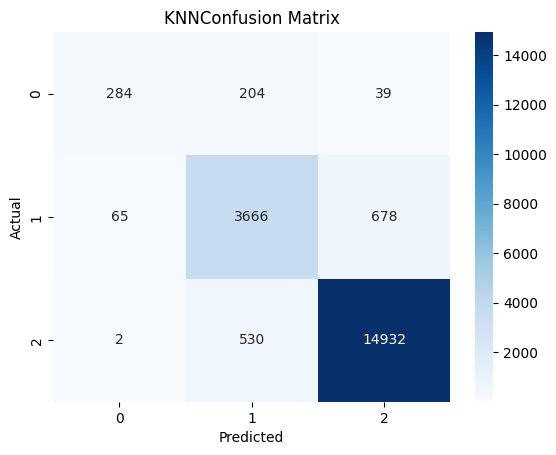


Logistic RegressionPerformance
Accuracy: 0.8923529411764706
Precision: 0.8906488265551291
Recall: 0.8923529411764706
F1 Score: 0.8906533945674451


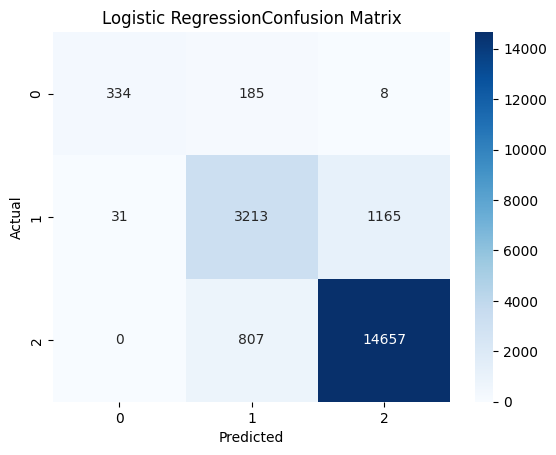

In [96]:
evaluate_model(y_test, y_pred_knn,"KNN")
evaluate_model(y_test, y_pred_lr,"Logistic Regression")

In [97]:
knn_acc=accuracy_score(y_test,y_pred_knn)
lr_acc=accuracy_score(y_test,y_pred_lr)
print("\nModel Comparison")
print("KNN Accuracy:",knn_acc)
print("Logistic Regression Accuracy:",lr_acc)
if knn_acc > lr_acc:
    print("Best Model:KNN")
else:
    print("Best Model:Logistic Regression")


Model Comparison
KNN Accuracy: 0.9255882352941176
Logistic Regression Accuracy: 0.8923529411764706
Best Model:KNN


In [98]:
# Decision Tree
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)
# SVM
svm=SVC()
svm.fit(X_train,y_train)
y_pred_svm=svm.predict(X_test)


Decision TreePerformance
Accuracy: 0.9695098039215686
Precision: 0.9694751881006887
Recall: 0.9695098039215686
F1 Score: 0.9694897640516195


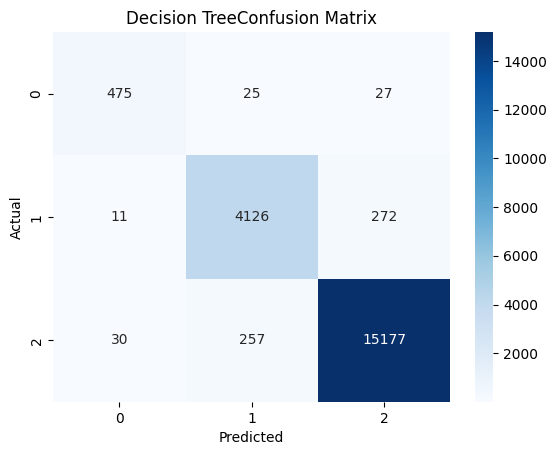


SVMPerformance
Accuracy: 0.9553921568627451
Precision: 0.9544773386491265
Recall: 0.9553921568627451
F1 Score: 0.9541902599009128


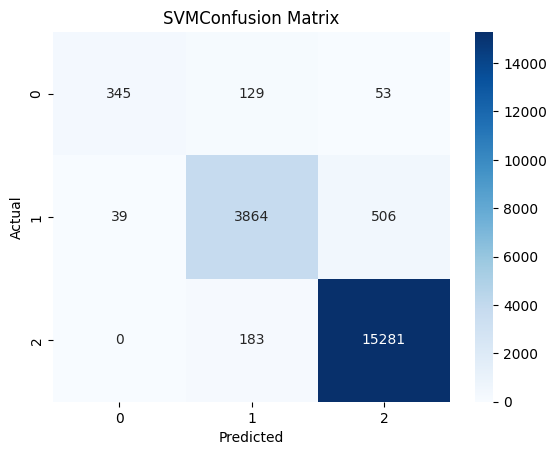

In [99]:
evaluate_model(y_test,y_pred_dt,'Decision Tree')
evaluate_model(y_test,y_pred_svm,'SVM')

In [100]:
dt_acc=accuracy_score(y_test,y_pred_dt)
svm_acc=accuracy_score(y_test,y_pred_svm)
print('Decision Tree Accuracy:',dt_acc)
print('SVM Accuracy:',svm_acc)

Decision Tree Accuracy: 0.9695098039215686
SVM Accuracy: 0.9553921568627451


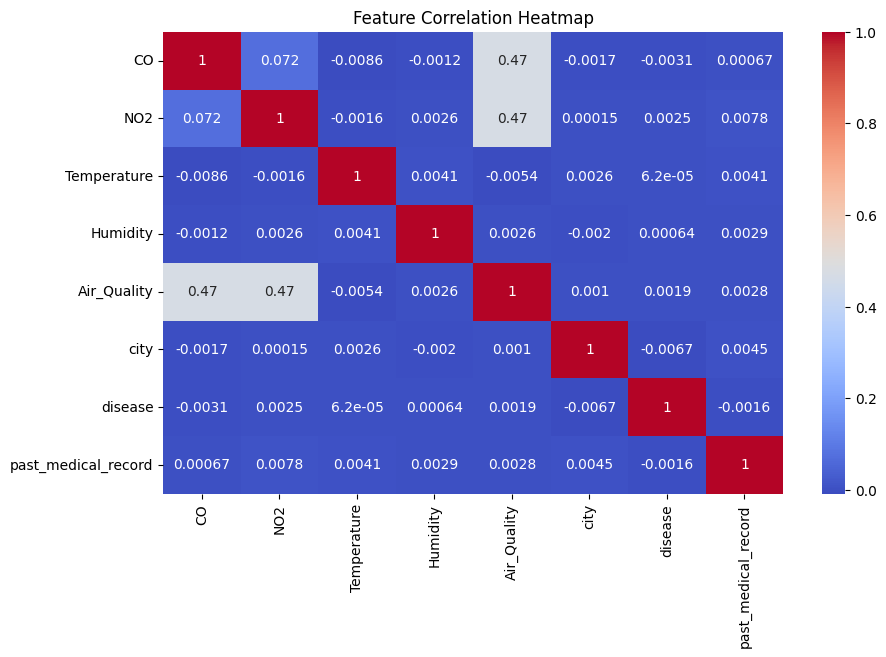

In [101]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [105]:
model_metrics={}
def store_metrics(name,y_test,y_pred):
    model_metrics[name]=[
        accuracy_score(y_test,y_pred),
        precision_score(y_test,y_pred,average='weighted'),
        recall_score(y_test,y_pred,average='weighted'),
        f1_score(y_test,y_pred,average='weighted')
    ]
store_metrics("KNN",y_test,y_pred_knn)
store_metrics("Logistic Regression",y_test,y_pred_lr)
store_metrics("Decision Tree",y_test,y_pred_dt)
store_metrics("SVM",y_test,y_pred_svm)

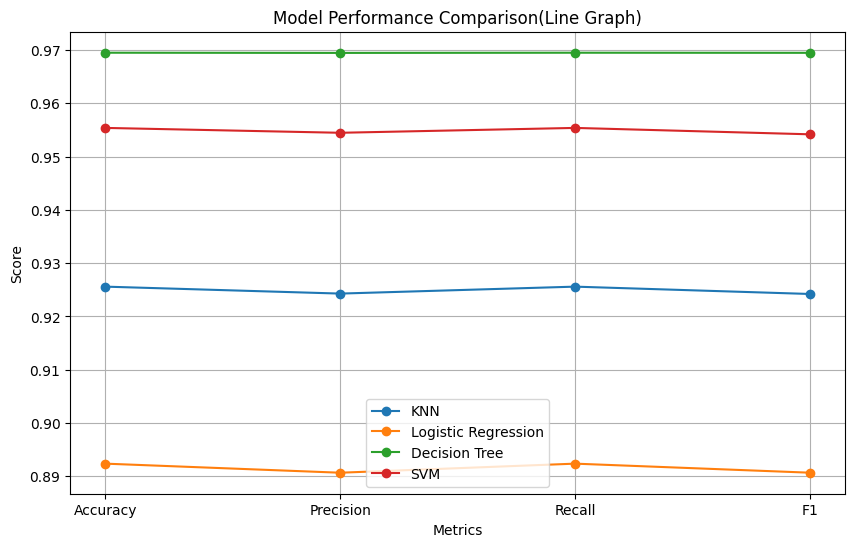

In [108]:
metrics=['Accuracy','Precision','Recall','F1']
knn_values=model_metrics['KNN']
lr_values=model_metrics['Logistic Regression']
dt_values=model_metrics['Decision Tree']
svm_values=model_metrics['SVM']
plt.figure(figsize=(10,6))
plt.plot(metrics,knn_values,marker='o',label='KNN')
plt.plot(metrics,lr_values,marker='o',label='Logistic Regression')
plt.plot(metrics,dt_values,marker='o',label='Decision Tree')
plt.plot(metrics,svm_values,marker='o',label='SVM')
plt.title("Model Performance Comparison(Line Graph)")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [111]:
model_metrics={}

In [112]:
def store_metrics(model_name,y_test,y_pred):
    model_metrics[model_name]={
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred,average='weighted'),
        "Recall":recall_score(y_test,y_pred,average='weighted'),
        "F1 Score":f1_score(y_test,y_pred,average='weighted')
    }

In [113]:
store_metrics("KNN",y_test,y_pred_knn)
store_metrics("Logistic Regression", y_test, y_pred_lr)
store_metrics("Decision Tree",y_test,y_pred_dt)
store_metrics("SVM",y_test,y_pred_svm)

In [114]:
metrics_df=pd.DataFrame(model_metrics).T
metrics_df

,Accuracy,Precision,Recall,F1 Score
KNN,0.925588,0.924283,0.925588,0.924210
Logistic Regression,0.892353,0.890649,0.892353,0.890653
Decision Tree,0.969510,0.969475,0.969510,0.969490
SVM,0.955392,0.954477,0.955392,0.954190


In [115]:
metrics_df=metrics_df.sort_values(by="Accuracy",ascending=False)
metrics_df

,Accuracy,Precision,Recall,F1 Score
Decision Tree,0.969510,0.969475,0.969510,0.969490
SVM,0.955392,0.954477,0.955392,0.954190
KNN,0.925588,0.924283,0.925588,0.924210
Logistic Regression,0.892353,0.890649,0.892353,0.890653


In [116]:
metrics_df=pd.DataFrame(model_metrics).T
metrics_df.sort_values(by="Accuracy",ascending=False)

,Accuracy,Precision,Recall,F1 Score
Decision Tree,0.969510,0.969475,0.969510,0.969490
SVM,0.955392,0.954477,0.955392,0.954190
KNN,0.925588,0.924283,0.925588,0.924210
Logistic Regression,0.892353,0.890649,0.892353,0.890653
